# **Understanding Query Similarities in SDPA**

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys

# Storage for captured queries per layer
# Structure: { layer_idx: [tensor_step_1, tensor_step_2, ...] }
captured_queries = {}

def get_query_hook(layer_idx):
    def hook(module, input, output):
        # Depending on the specific model architecture (e.g., LlamaAttention),
        # the query tensor might be structured slightly differently.
        # This example assumes standard projection outputs.
        
        # Output is typically a tuple or a tensor depending on the hook placement.
        # If hooking the `q_proj` layer directly:
        q = output.detach().cpu() 
        
        if layer_idx not in captured_queries:
            captured_queries[layer_idx] = []
        captured_queries[layer_idx].append(q)
    return hook

c:\Users\theep\anaconda3\envs\ai-training\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "mistralai/Mistral-7B-v0.1"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    attn_implementation="sdpa"  # <--- Changed from flash_attention_2 to sdpa
)

# Register hooks on specific layers (e.g., Layer 0, Layer 16, Layer 31)
layers_to_monitor = [0, 16, 31]
hooks = []

for idx in layers_to_monitor:
    # Adjust the attribute string depending on whether it's Llama, Mistral, etc.
    # For Mistral/Llama: model.model.layers[i].self_attn.q_proj
    target_layer = model.model.layers[idx].self_attn.q_proj
    hook_handle = target_layer.register_forward_hook(get_query_hook(idx))
    hooks.append(hook_handle)

Loading weights: 100%|██████████| 291/291 [00:20<00:00, 13.99it/s]


In [4]:
prompt = "The architecture of transformer networks allows for long-range context dependencies because"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Clear storage before running
captured_queries.clear()

# Generate N tokens (steps)
generation_steps = 1500
outputs = model.generate(
    **inputs, 
    max_new_tokens=generation_steps, 
    use_cache=True, # Critical to simulate real KV tracking
    do_sample=False
)

# Remove hooks when done to prevent memory leaks
for hook in hooks:
    hook.remove()

c:\Users\theep\anaconda3\envs\ai-training\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [15]:
print(f"Length of overall: {len(captured_queries)}")
print(f"Length of layer 0: {len(captured_queries[0])}")
print(f"Shape of query 0 layer 0: {captured_queries[0][0].shape}")
print(f"Shape of query 1 layer 0: {captured_queries[0][1].shape}")
print()
print(captured_queries[0][0][0, -1, :].view(model.config.num_attention_heads, -1))

Length of overall: 3
Length of layer 0: 636
Shape of query 0 layer 0: torch.Size([1, 15, 4096])
Shape of query 1 layer 0: torch.Size([1, 1, 4096])

tensor([[ 0.2061, -0.1318, -0.1216,  ..., -1.4844, -1.5781, -1.4453],
        [-0.0120,  0.2695, -0.3125,  ..., -1.8672, -2.3906, -1.8438],
        [ 0.0121,  0.2139, -0.2324,  ..., -1.5781, -2.0938, -1.7656],
        ...,
        [-0.3672,  0.4531, -3.8906,  ...,  2.8750,  2.6875, -3.1875],
        [ 0.2422,  0.4141,  0.2168,  ...,  0.6445,  0.3320, -0.8359],
        [-0.5820,  0.2617, -0.6133,  ...,  2.1562,  2.8906, -2.3906]],
       dtype=torch.bfloat16)


In [ ]:
def query_similarities(layer_idx):
    # Computes the cos similarity between the last query found after prefill (which represents the "state" of attention at the end of prefill) and the query of each token generated during decode (which allows a comparison of "states")

    num_heads = model.config.num_attention_heads

    # Step 1: Extract last query of prefill

    # All the queries for prefill
    q_prefill = captured_queries[layer_idx][0]

    # Get the last query from prefill (our comparison point for state)
    q_prefill = q_prefill[0, -1, :].view(num_heads, -1)

    # Get the decode queries
    q_decode = captured_queries[layer_idx][1:]

    # Shape becomes [num_steps, hidden_dim]
    q_decode = torch.stack(q_decode).squeeze(1).squeeze(1)

    q_decode = q_decode.view(len(q_decode), num_heads, -1)

    # Get Cosine Similarities
    head_curves = []

    for i in range(num_heads):
        h_q_prefill = F.normalize(q_prefill[i, :], p=2, dim=-1)

        h_q_decode = F.normalize(q_decode[:, i, :], p=2, dim=-1)

        cos_similarity = torch.mv(h_q_decode, h_q_prefill)

        head_curves.append(cos_similarity)

    return torch.stack(head_curves).float().cpu().numpy()


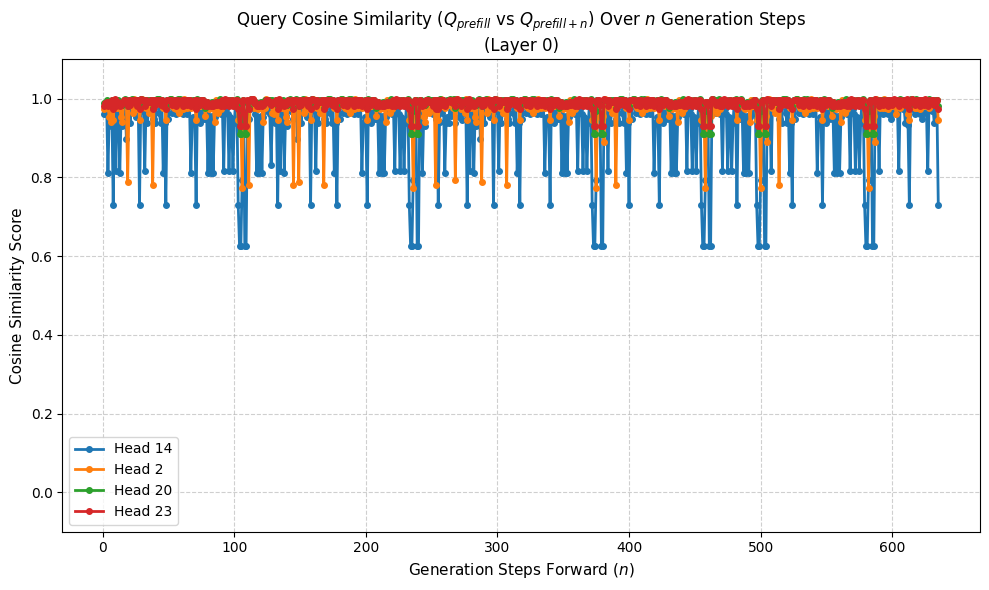

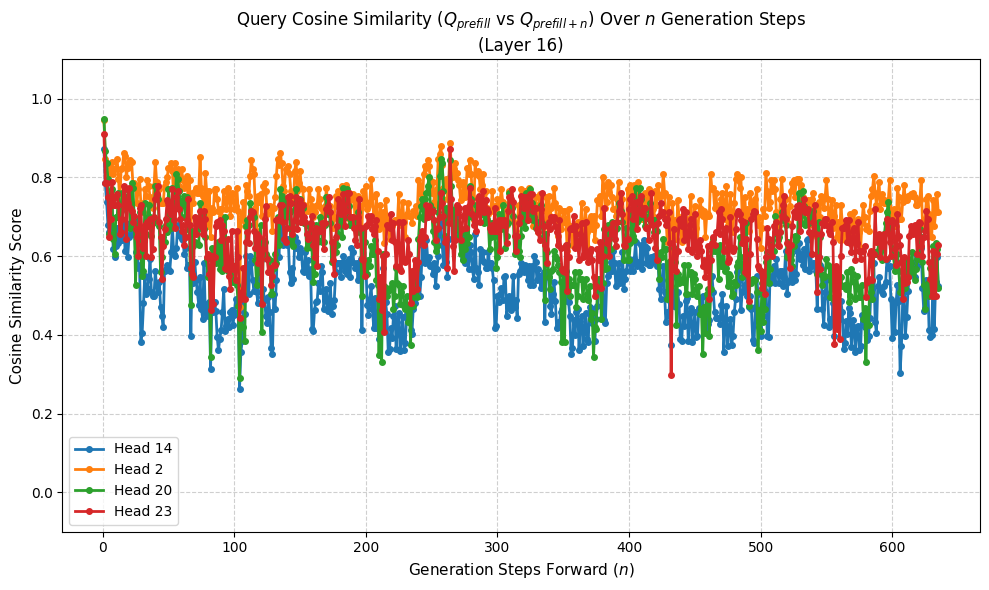

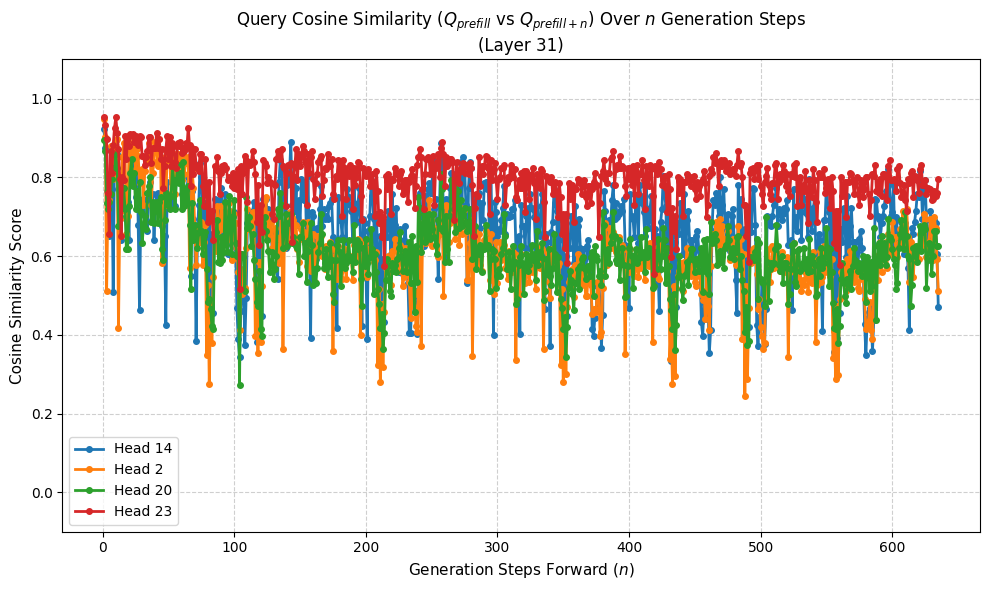

In [21]:
# Select the specific heads you want to visually compare
n_axis = np.arange(1, len(captured_queries[0])) # x-axis representing step n forward

rng = np.random.default_rng(seed=42)
heads_to_plot = rng.choice(32, size=4, replace=False)

for i in [0, 16, 31]:
    curves_per_head = query_similarities(layer_idx=i)

    plt.figure(i, figsize=(10, 6))

    for head_idx in heads_to_plot:
        plt.plot(
            n_axis, 
            curves_per_head[head_idx], 
            label=f"Head {head_idx}", 
            linewidth=2, 
            marker='o', 
            markersize=4
        )

    # Formatting the 2D plot
    plt.title(f"Query Cosine Similarity ($Q_{{prefill}}$ vs $Q_{{prefill+n}}$) Over $n$ Generation Steps\n(Layer {i})", fontsize=12)
    plt.xlabel("Generation Steps Forward ($n$)", fontsize=11)
    plt.ylabel("Cosine Similarity Score", fontsize=11)

    # Set explicit limits for clean tracking (Cosine similarity ranges from -1 to 1, usually stays > 0 here)
    plt.ylim(-0.1, 1.1) 
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="lower left", fontsize=10)

    plt.tight_layout()

plt.show()

In [25]:
conda install -c nvidia cuda-nvcc cuda-toolkit -y

^C

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%cd MiniKV/quant
!python -m pip install -e . --no-build-isolation
%cd ../..

In [ ]:
# 1. Ensure your notebook can find the cloned MiniKV repository path
minikv_path = os.path.abspath("./MiniKV")
if minikv_path not in sys.path:
    sys.path.append(minikv_path)

# 2. Import the two functions directly from your specific file
from monkeypatch.minikv_mistral_hijack_4_37 import (
    minikv_mistral_flash_attn2_forward,
    minikv_prepare_inputs_for_generation_mistral
)

# 3. Perform the live runtime hijack on the loaded transformers classes
# This swaps out the standard FlashAttention2 forward pass with MiniKV's logic
transformers.models.mistral.modeling_mistral.MistralFlashAttention2.forward = minikv_mistral_flash_attn2_forward

# This swaps out the standard generation loop setup with MiniKV's QuantizedCache initialization
transformers.models.mistral.modeling_mistral.MistralForCausalLM.prepare_inputs_for_generation = minikv_prepare_inputs_for_generation_mistral

print("Mistral model successfully hijacked with MiniKV functions!")

In [ ]:
# Create a global dictionary that the hijacked function can write to
import monkeypatch.minikv_mistral_hijack_4_37 as hijack_mod

hijack_mod.minikv_captured_queries = {}
hijack_mod.is_prefill_phase = True

print("Query storage containers initialized.")

ModuleNotFoundError: No module named 'monkeypatch'

In [ ]:
model_id = "mistralai/Mistral-7B-v0.1"  # Replace with your specific path

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    device_map="auto"
)

# Apply MiniKV parameters directly onto the config target
model.config.quant_bits = 2               
model.config.group_size = 16
model.config.residual_length = 128        
model.config.heavy_ratio = 0.1
model.config.recent_ratio = 0.1
model.config.eviction_strategy = "pyramid"
model.config.use_eviction_flash = False   # Keeps standard PyTorch math paths open

print("Model successfully loaded with MiniKV configurations.")

Important point above: We are able to use flash attention for this model since we are logging the queries manually from the source file. Flash attention was not practical for the SPDA alternative because it hides the intermediate PyTorch variables (in transformers HuggingFace library).

In [ ]:
# Clear any prior remnants out of the logging block
hijack_mod.minikv_captured_queries.clear()
hijack_mod.is_prefill_phase = True

prompt = "The architecture of transformer networks allows for long-range context dependencies because"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

print("Running generation...")
outputs = model.generate(
    **inputs, 
    max_new_tokens=1500, 
    use_cache=True, 
    do_sample=False,
)
print("Generation finished.")